In [5]:
# ==========================================
# CodeAlpha Task 3
# Handwritten Character Recognition
# Environment Setup
# ==========================================

import sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import sklearn

print("Python version:", sys.version)
print("NumPy version:", np.__version__)
print("TensorFlow version:", tf.__version__)
print("Scikit-learn version:", sklearn.__version__)

print("\nEnvironment setup successful!")

Python version: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
NumPy version: 2.1.3
TensorFlow version: 2.20.0
Scikit-learn version: 1.6.1

Environment setup successful!


In [6]:
# Check whether a GPU is available

gpu_devices = tf.config.list_physical_devices("GPU")

if gpu_devices:
    print("GPU available:", gpu_devices)
else:
    print("GPU not available. CPU will be used.")

GPU not available. CPU will be used.


In [7]:
# ==========================================
# Step 2: Load MNIST Dataset
# ==========================================

from tensorflow.keras.datasets import mnist

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Display dataset information
print("MNIST Dataset Loaded Successfully!\n")

print("Training images shape :", x_train.shape)
print("Training labels shape :", y_train.shape)
print("Testing images shape  :", x_test.shape)
print("Testing labels shape  :", y_test.shape)

print("\nNumber of training images:", len(x_train))
print("Number of testing images :", len(x_test))
print("Image dimensions         :", x_train.shape[1], "x", x_train.shape[2])
print("Number of classes        :", len(np.unique(y_train)))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST Dataset Loaded Successfully!

Training images shape : (60000, 28, 28)
Training labels shape : (60000,)
Testing images shape  : (10000, 28, 28)
Testing labels shape  : (10000,)

Number of training images: 60000
Number of testing images : 10000
Image dimensions         : 28 x 28
Number of classes        : 10


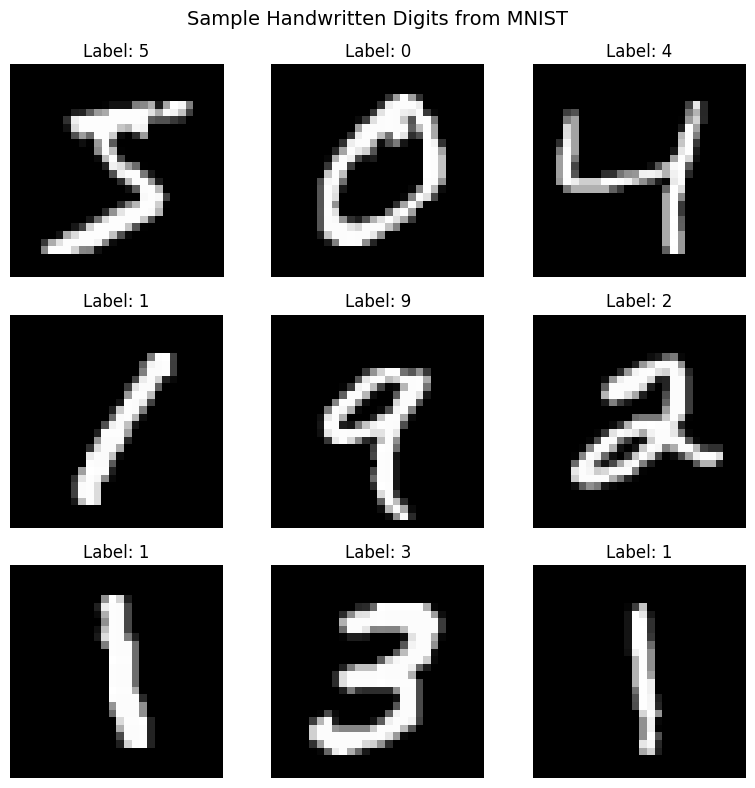

In [8]:
# ==========================================
# Step 3: Visualize MNIST Images
# ==========================================

import matplotlib.pyplot as plt

# Create a 3x3 grid
plt.figure(figsize=(8, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.suptitle("Sample Handwritten Digits from MNIST", fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# ==========================================
# Step 4: Data Preprocessing
# ==========================================

# Normalize pixel values from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add the grayscale channel dimension
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Display the new shapes and value range
print("After preprocessing:\n")

print("Training images shape :", x_train.shape)
print("Testing images shape  :", x_test.shape)

print("\nMinimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

After preprocessing:

Training images shape : (60000, 28, 28, 1)
Testing images shape  : (10000, 28, 28, 1)

Minimum pixel value: 0.0
Maximum pixel value: 1.0


Number of images for each digit:

Digit 0: 5923
Digit 1: 6742
Digit 2: 5958
Digit 3: 6131
Digit 4: 5842
Digit 5: 5421
Digit 6: 5918
Digit 7: 6265
Digit 8: 5851
Digit 9: 5949


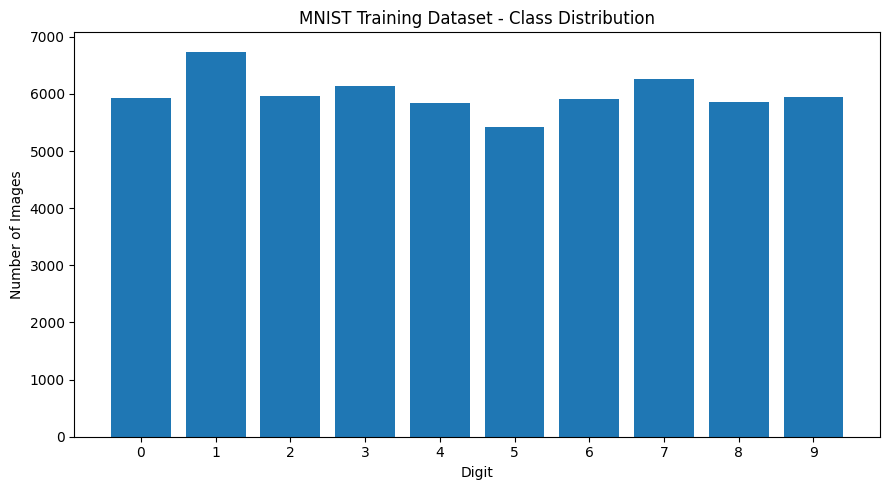

In [10]:
# ==========================================
# Step 5: Exploratory Data Analysis
# Class Distribution
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

# Count the number of samples for each digit
class_counts = np.bincount(y_train, minlength=10)

# Display the counts
print("Number of images for each digit:\n")

for digit, count in enumerate(class_counts):
    print(f"Digit {digit}: {count}")

# Plot class distribution
plt.figure(figsize=(9, 5))

plt.bar(range(10), class_counts)

plt.title("MNIST Training Dataset - Class Distribution")
plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.xticks(range(10))

plt.tight_layout()
plt.show()

In [11]:
# ==========================================
# Step 6: Build CNN Model - Clean Version
# ==========================================

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# Create the CNN model
model = Sequential([
    # Input layer
    Input(shape=(28, 28, 1)),

    # First convolutional layer
    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu"
    ),

    # First pooling layer
    MaxPooling2D(pool_size=(2, 2)),

    # Second convolutional layer
    Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu"
    ),

    # Second pooling layer
    MaxPooling2D(pool_size=(2, 2)),

    # Flatten feature maps
    Flatten(),

    # Fully connected layer
    Dense(128, activation="relu"),

    # Dropout to reduce overfitting
    Dropout(0.5),

    # Output layer for 10 digits
    Dense(10, activation="softmax")
])

# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# ==========================================
# Step 7: Compile CNN Model
# ==========================================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN model compiled successfully!")

CNN model compiled successfully!


In [13]:
# ==========================================
# Step 8: Train the CNN Model
# ==========================================

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

print("\nModel training completed successfully!")

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 49s 112ms/step - accuracy: 0.9067 - loss: 0.3074 - val_accuracy: 0.9820 - val_loss: 0.0649
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 79s 106ms/step - accuracy: 0.9703 - loss: 0.0999 - val_accuracy: 0.9852 - val_loss: 0.0473
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 104ms/step - accuracy: 0.9784 - loss: 0.0724 - val_accuracy: 0.9892 - val_loss: 0.0367
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 102ms/step - accuracy: 0.9824 - loss: 0.0583 - val_accuracy: 0.9900 - val_loss: 0.0347
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 105ms/step - accuracy: 0.9846 - loss: 0.0510 - val_accuracy: 0.9895 - val_loss: 0.0341
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 102ms/step - accuracy: 0.9867 - loss: 0.0441 - val_accuracy: 0.9918 - val_loss: 0.0340
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 101ms/step - accuracy: 0.9874 - loss: 0.0418 - val_accuracy: 0.9907 - val_loss: 0.0326
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 104ms/step - accuracy: 0.9890 - loss: 0

In [14]:
# ==========================================
# Step 9: Evaluate CNN Model
# ==========================================

# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

# Display the results
print("\n========== Test Results ==========")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4%}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9920 - loss: 0.0260

========== Test Results ==========
Test Loss     : 0.0260
Test Accuracy : 99.2000%


In [15]:
# ==========================================
# Step 10: Classification Metrics
# ==========================================

from sklearn.metrics import classification_report

# Generate probability predictions
y_probability = model.predict(x_test, verbose=0)

# Convert probabilities to predicted class labels
y_pred = np.argmax(y_probability, axis=1)

# Generate classification report
report = classification_report(
    y_test,
    y_pred,
    digits=4
)

print("========== Classification Report ==========\n")
print(report)

========== Classification Report ==========

              precision    recall  f1-score   support

           0     0.9899    0.9980    0.9939       980
           1     0.9904    0.9991    0.9947      1135
           2     0.9961    0.9874    0.9917      1032
           3     0.9940    0.9911    0.9926      1010
           4     0.9939    0.9959    0.9949       982
           5     0.9899    0.9877    0.9888       892
           6     0.9979    0.9896    0.9937       958
           7     0.9836    0.9942    0.9889      1028
           8     0.9918    0.9897    0.9908       974
           9     0.9930    0.9861    0.9896      1009

    accuracy                         0.9920     10000
   macro avg     0.9921    0.9919    0.9920     10000
weighted avg     0.9920    0.9920    0.9920     10000



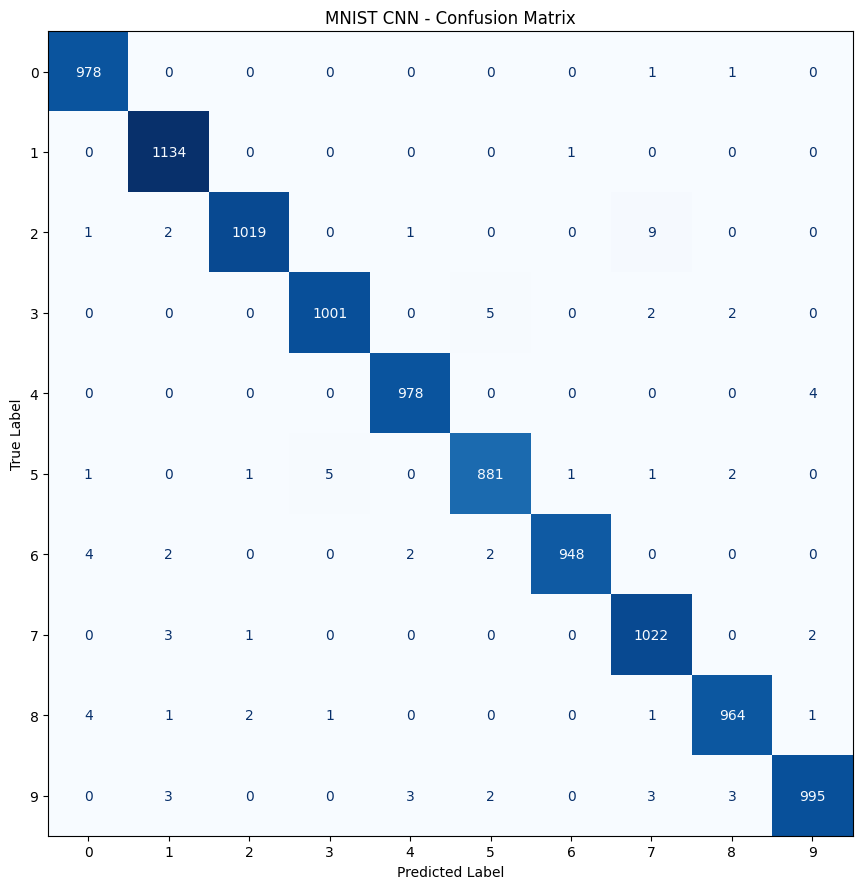

In [16]:
# ==========================================
# Step 11: Confusion Matrix
# ==========================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create the confusion matrix display
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(9, 9))

display.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

ax.set_title("MNIST CNN - Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

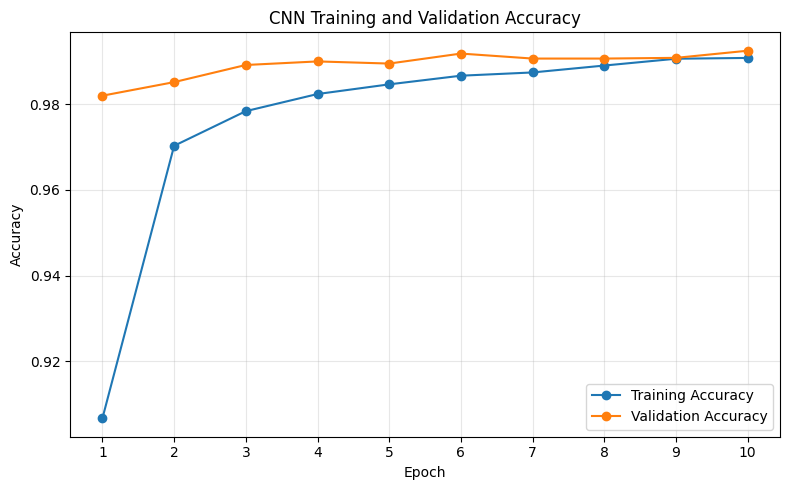

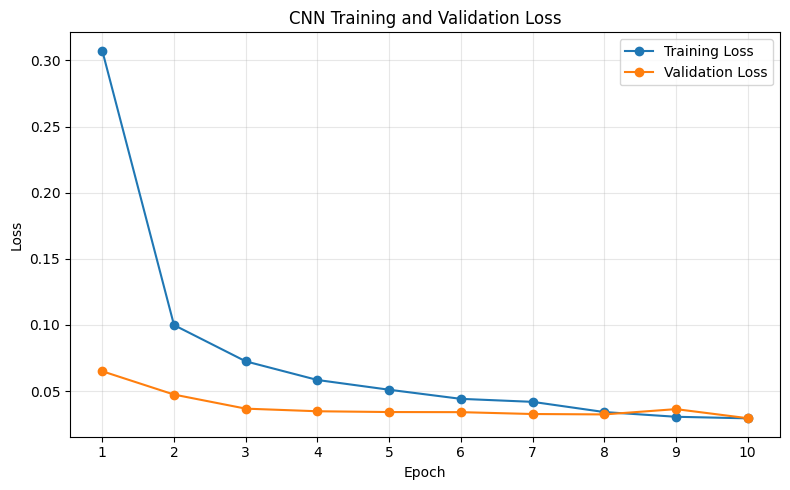

In [17]:
# ==========================================
# Step 12: Training Performance Graphs
# ==========================================

# Get training history
training_accuracy = history.history["accuracy"]
validation_accuracy = history.history["val_accuracy"]

training_loss = history.history["loss"]
validation_loss = history.history["val_loss"]

epochs = range(1, len(training_accuracy) + 1)

# ------------------------------------------
# Accuracy Graph
# ------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    training_accuracy,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    validation_accuracy,
    marker="o",
    label="Validation Accuracy"
)

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------
# Loss Graph
# ------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    training_loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    validation_loss,
    marker="o",
    label="Validation Loss"
)

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

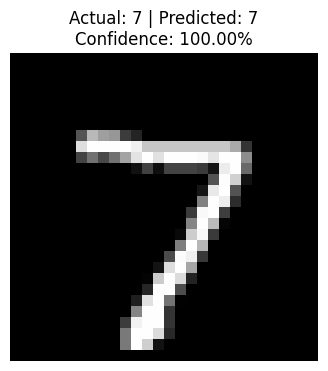

========== Prediction Result ==========
Actual digit     : 7
Predicted digit  : 7
Confidence       : 100.00%


In [18]:
# ==========================================
# Step 13: Digit Prediction System
# ==========================================

# Select one image from the test dataset
sample_index = 0

# Get the image and actual label
sample_image = x_test[sample_index]
actual_label = y_test[sample_index]

# Predict the digit
prediction_probabilities = model.predict(
    sample_image.reshape(1, 28, 28, 1),
    verbose=0
)

# Get the predicted digit
predicted_digit = np.argmax(prediction_probabilities[0])

# Get prediction confidence
confidence = np.max(prediction_probabilities[0]) * 100

# Display the image
plt.figure(figsize=(4, 4))
plt.imshow(sample_image.squeeze(), cmap="gray")
plt.title(
    f"Actual: {actual_label} | "
    f"Predicted: {predicted_digit}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.axis("off")
plt.show()

# Print prediction details
print("========== Prediction Result ==========")
print("Actual digit     :", actual_label)
print("Predicted digit  :", predicted_digit)
print(f"Confidence       : {confidence:.2f}%")

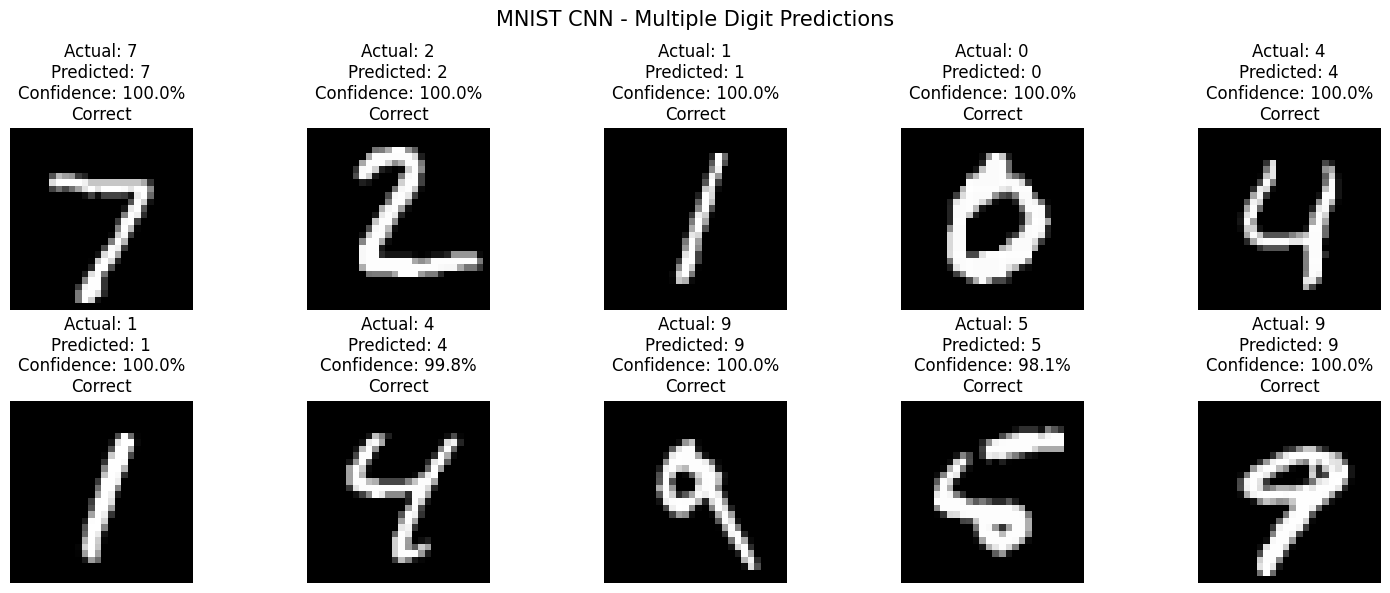

In [19]:
# ==========================================
# Step 14: Multiple Digit Predictions
# ==========================================

# Number of images to test
num_images = 10

# Create a figure
plt.figure(figsize=(15, 6))

for i in range(num_images):

    # Get the image and actual label
    image = x_test[i]
    actual_label = y_test[i]

    # Predict the digit
    probabilities = model.predict(
        image.reshape(1, 28, 28, 1),
        verbose=0
    )

    # Get predicted digit and confidence
    predicted_digit = np.argmax(probabilities[0])
    confidence = np.max(probabilities[0]) * 100

    # Display image
    plt.subplot(2, 5, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")

    # Mark correct/incorrect prediction in the title
    result = "Correct" if predicted_digit == actual_label else "Incorrect"

    plt.title(
        f"Actual: {actual_label}\n"
        f"Predicted: {predicted_digit}\n"
        f"Confidence: {confidence:.1f}%\n"
        f"{result}"
    )

    plt.axis("off")

plt.suptitle(
    "MNIST CNN - Multiple Digit Predictions",
    fontsize=15
)

plt.tight_layout()
plt.show()

Saving ChatGPT Image Sep 6, 2026, 01_38_31 PM.png to ChatGPT Image Sep 6, 2026, 01_38_31 PM.png


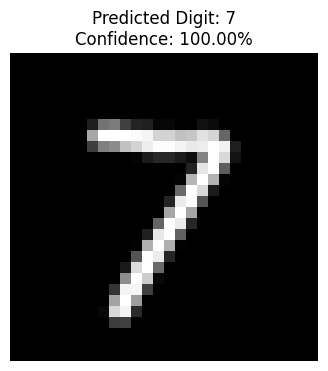

========== Custom Image Prediction ==========
Uploaded file    : ChatGPT Image Sep 6, 2026, 01_38_31 PM.png
Predicted digit  : 7
Confidence       : 100.00%


In [20]:
# ==========================================
# Step 15: Custom Handwritten Digit Prediction
# ==========================================

from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Upload an image
uploaded = files.upload()

# Get the uploaded filename
file_name = next(iter(uploaded))

# Open the image
image = Image.open(file_name).convert("L")

# Resize to MNIST size
image = image.resize((28, 28))

# Convert image to NumPy array
image_array = np.array(image, dtype="float32")

# Check whether the background is dark.
# MNIST uses a dark background with a bright digit.
# If the image has a bright background, invert it.
if image_array.mean() > 127:
    image_array = 255.0 - image_array

# Normalize pixel values
image_array = image_array / 255.0

# Add batch and channel dimensions
input_image = image_array.reshape(1, 28, 28, 1)

# Make prediction
probabilities = model.predict(input_image, verbose=0)[0]

# Get predicted digit
predicted_digit = int(np.argmax(probabilities))

# Get confidence
confidence = float(np.max(probabilities) * 100)

# Display the uploaded image
plt.figure(figsize=(4, 4))
plt.imshow(image_array, cmap="gray")
plt.title(
    f"Predicted Digit: {predicted_digit}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.axis("off")
plt.show()

# Display prediction result
print("========== Custom Image Prediction ==========")
print("Uploaded file    :", file_name)
print("Predicted digit  :", predicted_digit)
print(f"Confidence       : {confidence:.2f}%")

Total test images       : 10000
Incorrect predictions   : 80
Correct predictions     : 9920
Test accuracy           : 99.20%


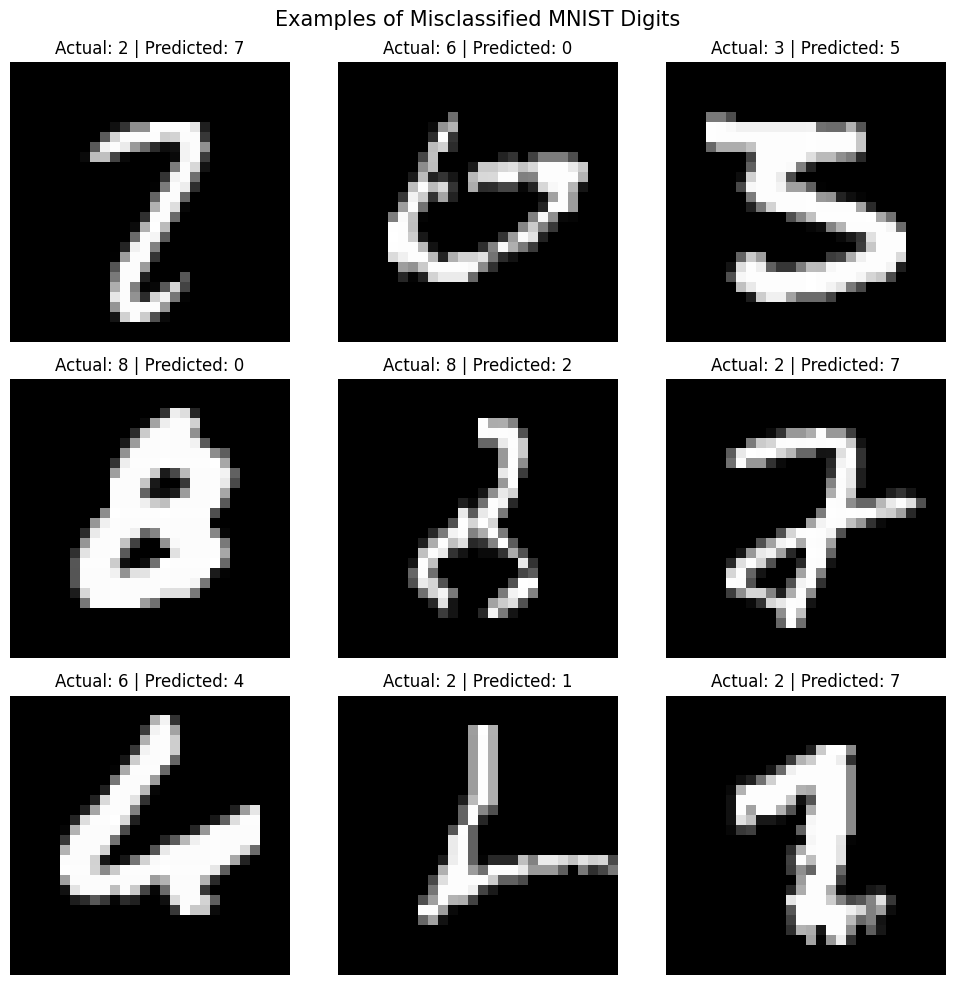

In [21]:
# ==========================================
# Step 16: Error Analysis
# ==========================================

# Find incorrectly classified images
incorrect_indices = np.where(y_pred != y_test)[0]

print("Total test images       :", len(y_test))
print("Incorrect predictions   :", len(incorrect_indices))
print("Correct predictions     :", len(y_test) - len(incorrect_indices))
print("Test accuracy           :", f"{test_accuracy:.2%}")

# Display up to 9 incorrectly classified images
num_errors_to_display = min(9, len(incorrect_indices))

plt.figure(figsize=(10, 10))

for i in range(num_errors_to_display):
    index = incorrect_indices[i]

    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[index].squeeze(), cmap="gray")

    plt.title(
        f"Actual: {y_test[index]} | "
        f"Predicted: {y_pred[index]}"
    )

    plt.axis("off")

plt.suptitle("Examples of Misclassified MNIST Digits", fontsize=15)
plt.tight_layout()
plt.show()

In [22]:
# Save the trained model

model.save("handwritten_character_recognition.keras")

print("Model saved successfully!")

Model saved successfully!


In [23]:
import os

file_path = "handwritten_character_recognition.keras"

if os.path.exists(file_path):
    file_size = os.path.getsize(file_path) / (1024 * 1024)
    print(f"Model file exists: {file_path}")
    print(f"File size: {file_size:.2f} MB")
else:
    print("Model file was not found.")

Model file exists: handwritten_character_recognition.keras
File size: 2.61 MB


In [24]:
model.save("handwritten_character_recognition.keras")

print("Model saved successfully in Colab!")

Model saved successfully in Colab!


In [25]:
import os

print(os.path.exists("handwritten_character_recognition.keras"))

True


In [26]:
from tensorflow.keras.models import load_model

loaded_model = load_model("handwritten_character_recognition.keras")

print("Model loaded successfully!")

Model loaded successfully!
